In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pathlib as pl

In [2]:
experiment_paths = [path for path in pl.Path().glob(pattern='*') if path.is_dir()]

In [3]:
def read_data(path: pl.Path):
	data = pd.read_csv(path / 'solver_data.csv')
	V0s = np.sort(data['V0'].unique())
	dTs = np.sort(data['dT'].unique())

	grids = {col: data[col].to_numpy().reshape([len(dTs), len(V0s)]).T[::-1] for col in data.columns} # top row should be highest V0 value
	grids['f'] = np.abs(grids['f1']) + np.abs(grids['f2'])
	grids['f_log'] = np.full(shape=[len(V0s), len(dTs)], fill_value=np.nan)
	np.log10(grids['f']+1e-20, out=grids['f_log'], where=~grids['diverged'])
	
	approx_data = pd.read_csv(path / 'approx_data.csv')
	approx_v = approx_data['V'].to_numpy()[np.newaxis, :]
	percent_error = 100 * np.abs(grids['V'] -  approx_v) / approx_v
	percent_error[grids['diverged']] = np.nan

	return approx_data, V0s, dTs, grids, percent_error

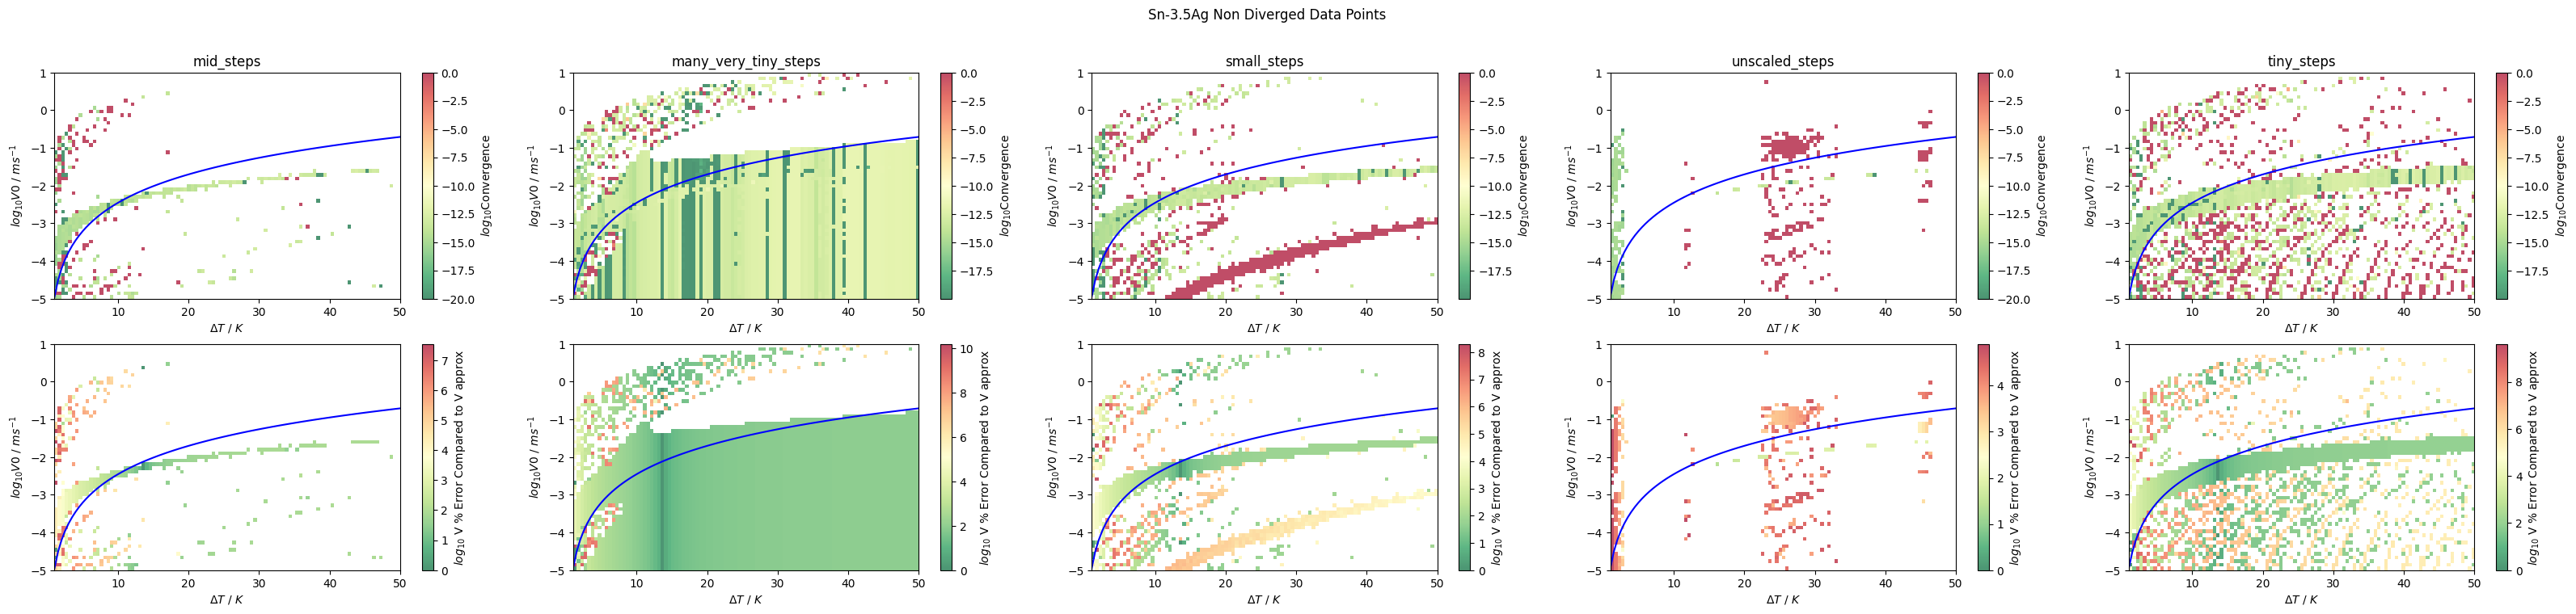

In [5]:
fig, axes = plt.subplots(nrows=2, ncols=len(experiment_paths), figsize=(40,8))
fig.suptitle('Sn-3.5Ag Non Diverged Data Points')

for i, path in enumerate(experiment_paths):
	axes[0, i].set_title(path)
	approx_data, V0s, dTs, grids, percent_error = read_data(path)

	for row in (0, 1):
		axes[row, i].plot(approx_data['dT'], np.log10(approx_data['V']), color='blue')
		axes[row, i].set_xlabel(r'$\Delta T$ / $K$')
		axes[row, i].set_ylabel(r'$log_{10}V0$ / $ms^{-1}$')

	f_im = axes[0, i].imshow(
		grids['f_log'], vmax=0, extent=(dTs.min(), dTs.max(), np.log10(V0s.min()), np.log10(V0s.max())),
		aspect='auto', alpha=0.7, cmap='RdYlGn_r'
	)
	fig.colorbar(f_im, label=r'$log_{10}$Convergence')

	error_im = axes[1, i].imshow(
		np.log10(percent_error),
		# np.ma.masked_where(~grids['converged'], np.log10(percent_error)),
		extent=(dTs.min(), dTs.max(), np.log10(V0s.min()), np.log10(V0s.max())),
		vmin=0, aspect='auto', alpha=0.7, cmap='RdYlGn_r',
		# vmax=3
	)
	fig.colorbar(error_im, label=r'$log_{10}$ V % Error Compared to V approx')
